# 05 — Regression: Predicting pIC50 (Random Forest vs SVR)

**Input:** `data/processed/btk_fps.csv` (9436 molecules × 2.048 bits)  
**Output:** trained regressors in `models/`, metrics in `results/`

Unlike notebook 04 (binary classification: active/inactive), here we predict
the **continuous pIC50 value** directly. This preserves potency information
lost by the binary threshold — e.g., distinguishing a pIC50=9.5 compound
from a pIC50=6.1 compound, both labeled "active" in the classification task.

Steps:
1. Load fingerprint dataset, prepare X (fingerprints) and y (pIC50)
2. Train/test split
3. Random Forest Regressor — cross-validation
4. SVR — cross-validation
5. Compare CV results
6. Final test set evaluation
7. Predicted vs actual plots
8. Save trained models

## 1. Imports and Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

INPUT_PATH = '../data/processed/btk_fps.csv'
RANDOM_STATE = 42

df = pd.read_csv(INPUT_PATH)
print(f'Loaded: {df.shape[0]} molecules, {df.shape[1]} columns')

Loaded: 9436 molecules, 2051 columns


## 2. Prepare X and y

- `X`: same 2.048 fingerprint bits as notebook 04
- `y`: now the **continuous `pIC50` value**, not the binary `activity` label

In [2]:
bit_cols = [c for c in df.columns if c.startswith('bit_')]

X = df[bit_cols].values
y = df['pIC50'].values

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'pIC50 range: {y.min():.2f} - {y.max():.2f}')
print(f'pIC50 mean:  {y.mean():.2f} (std: {y.std():.2f})')

X shape: (9436, 2048)
y shape: (9436,)
pIC50 range: 3.00 - 12.59
pIC50 mean:  7.54 (std: 1.17)


## 3. Train/Test Split

No `stratify` needed here — that's a classification concept for balancing
discrete classes. For regression we just do a plain random split.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

print(f'Train set: {X_train.shape[0]} molecules')
print(f'Test set:  {X_test.shape[0]} molecules')

Train set: 7548 molecules
Test set:  1888 molecules


## 4. Cross-Validation Setup

Plain `KFold` (not stratified — that doesn't apply to continuous targets).
Metrics: **R²** (variance explained, 0-1, higher is better) and
**RMSE** (average error in pIC50 units, lower is better).

In [4]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    'r2': 'r2',
    'rmse': 'neg_root_mean_squared_error',
    'mae': 'neg_mean_absolute_error'
}

print('Cross-validation configured: 5-fold KFold')

Cross-validation configured: 5-fold KFold


## 5. Random Forest Regressor — Cross-Validation

In [5]:
rf_reg = RandomForestRegressor(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

print('Running 5-fold cross-validation for Random Forest Regressor...')
rf_cv_results = cross_validate(rf_reg, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)

print('\n=== Random Forest Regressor — Cross-Validation Results ===')
print(f"R2:   {rf_cv_results['test_r2'].mean():.3f} \u00b1 {rf_cv_results['test_r2'].std():.3f}")
print(f"RMSE: {-rf_cv_results['test_rmse'].mean():.3f} \u00b1 {rf_cv_results['test_rmse'].std():.3f}")
print(f"MAE:  {-rf_cv_results['test_mae'].mean():.3f} \u00b1 {rf_cv_results['test_mae'].std():.3f}")

Running 5-fold cross-validation for Random Forest Regressor...

=== Random Forest Regressor — Cross-Validation Results ===
R2:   0.654 ± 0.014
RMSE: 0.685 ± 0.011
MAE:  0.496 ± 0.006


## 6. SVR — Cross-Validation

Same scaling rationale as notebook 04: `StandardScaler` inside a Pipeline,
since SVR is sensitive to feature scale (more so than RF).

In [6]:
from sklearn.model_selection import ShuffleSplit

# SVR is computationally expensive with large datasets.
# We train on a subsample of 3000 molecules to keep runtime feasible.
ss = ShuffleSplit(n_splits=1, train_size=3000, random_state=RANDOM_STATE)
idx_sub, _ = next(ss.split(X_train, y_train))
X_train_svr = X_train[idx_sub]
y_train_svr = y_train[idx_sub]

print(f'SVR subsample: {len(y_train_svr)} molecules')

svr = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR(kernel='rbf'))
])

print('Running 5-fold cross-validation for SVR (subsampled to n=3000)...')
svr_cv_results = cross_validate(svr, X_train_svr, y_train_svr, cv=cv, scoring=scoring, n_jobs=-1)

print('\n=== SVR — Cross-Validation Results (subsample n=3000) ===')
print(f"R2:   {svr_cv_results['test_r2'].mean():.3f} ± {svr_cv_results['test_r2'].std():.3f}")
print(f"RMSE: {-svr_cv_results['test_rmse'].mean():.3f} ± {svr_cv_results['test_rmse'].std():.3f}")
print(f"MAE:  {-svr_cv_results['test_mae'].mean():.3f} ± {svr_cv_results['test_mae'].std():.3f}")

SVR subsample: 3000 molecules
Running 5-fold cross-validation for SVR (subsampled to n=3000)...

=== SVR — Cross-Validation Results (subsample n=3000) ===
R2:   0.469 ± 0.040
RMSE: 0.843 ± 0.043
MAE:  0.648 ± 0.030


## 7. Compare CV Results — RF vs SVR

=== CV Comparison (mean across 5 folds) ===
      Random Forest    SVR
R2            0.654  0.469
RMSE          0.685  0.843
MAE           0.496  0.648


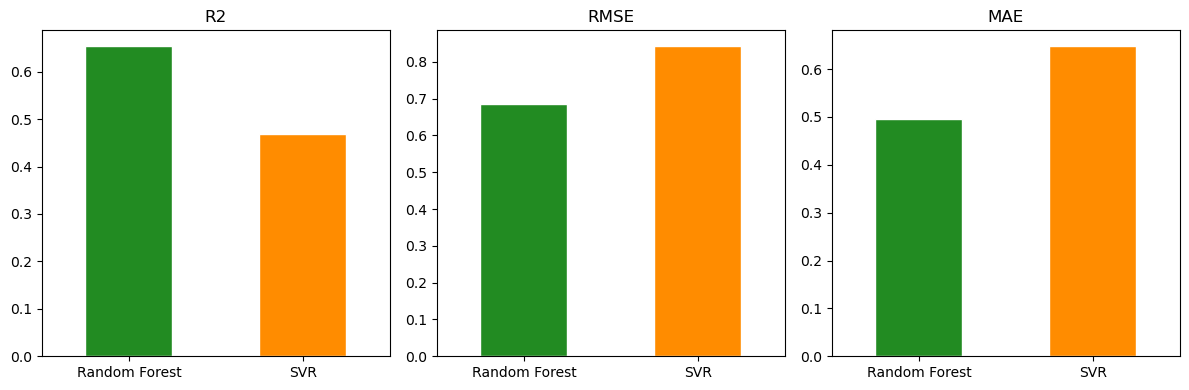

Plot saved to results/


In [7]:
comparison = pd.DataFrame({
    'Random Forest': [
        rf_cv_results['test_r2'].mean(),
        -rf_cv_results['test_rmse'].mean(),
        -rf_cv_results['test_mae'].mean()
    ],
    'SVR': [
        svr_cv_results['test_r2'].mean(),
        -svr_cv_results['test_rmse'].mean(),
        -svr_cv_results['test_mae'].mean()
    ],
}, index=['R2', 'RMSE', 'MAE'])

print('=== CV Comparison (mean across 5 folds) ===')
print(comparison.round(3))

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, metric in zip(axes, comparison.index):
    comparison.loc[metric].plot(kind='bar', ax=ax, color=['forestgreen', 'darkorange'], edgecolor='white')
    ax.set_title(metric)
    ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig('../results/05_cv_comparison.png', dpi=150)
plt.show()
print('Plot saved to results/')

## 8. Final Training and Test Set Evaluation

In [8]:
rf_reg.fit(X_train, y_train)
svr.fit(X_train_svr, y_train_svr)

rf_pred  = rf_reg.predict(X_test)
svr_pred = svr.predict(X_test)

def print_regression_metrics(name, y_true, y_pred):
    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    print(f'=== {name} \u2014 Test Set Performance ===')
    print(f'R2:   {r2:.3f}')
    print(f'RMSE: {rmse:.3f}')
    print(f'MAE:  {mae:.3f}')
    print()
    return r2, rmse, mae

rf_r2, rf_rmse, rf_mae   = print_regression_metrics('Random Forest', y_test, rf_pred)
svr_r2, svr_rmse, svr_mae = print_regression_metrics('SVR', y_test, svr_pred)

=== Random Forest — Test Set Performance ===
R2:   0.657
RMSE: 0.703
MAE:  0.509

=== SVR — Test Set Performance ===
R2:   0.506
RMSE: 0.845
MAE:  0.638



## 9. Predicted vs Actual Plots

The closer the points sit to the diagonal line, the better the prediction.
This is the standard visual diagnostic for regression in QSAR.

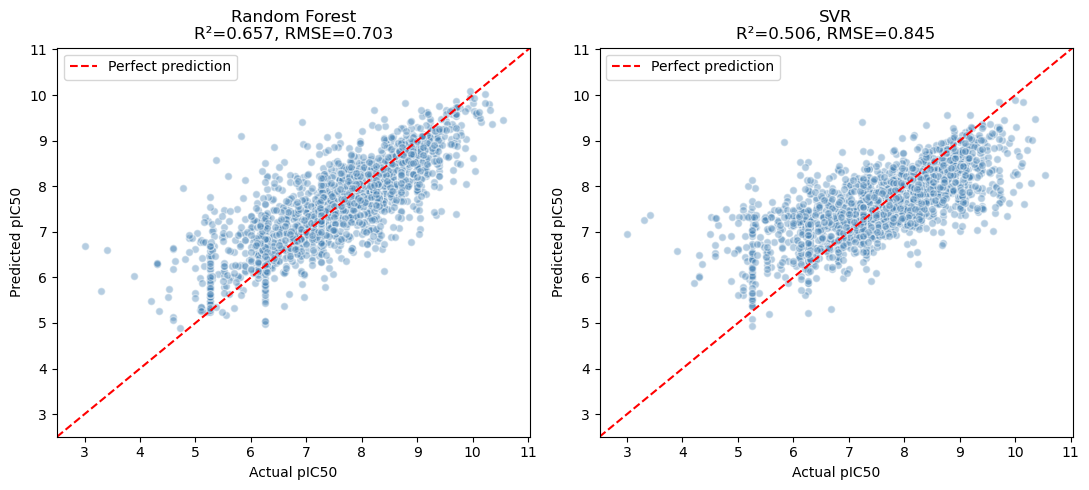

Plot saved to results/


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for ax, (name, pred, r2, rmse) in zip(
    axes,
    [('Random Forest', rf_pred, rf_r2, rf_rmse), ('SVR', svr_pred, svr_r2, svr_rmse)]
):
    ax.scatter(y_test, pred, alpha=0.4, color='steelblue', edgecolor='white', s=30)
    lims = [min(y_test.min(), pred.min()) - 0.5, max(y_test.max(), pred.max()) + 0.5]
    ax.plot(lims, lims, linestyle='--', color='red', label='Perfect prediction')
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel('Actual pIC50')
    ax.set_ylabel('Predicted pIC50')
    ax.set_title(f'{name}\nR\u00b2={r2:.3f}, RMSE={rmse:.3f}')
    ax.legend()

plt.tight_layout()
plt.savefig('../results/05_predicted_vs_actual.png', dpi=150)
plt.show()
print('Plot saved to results/')

## 10. Feature Importance (Random Forest Regressor)

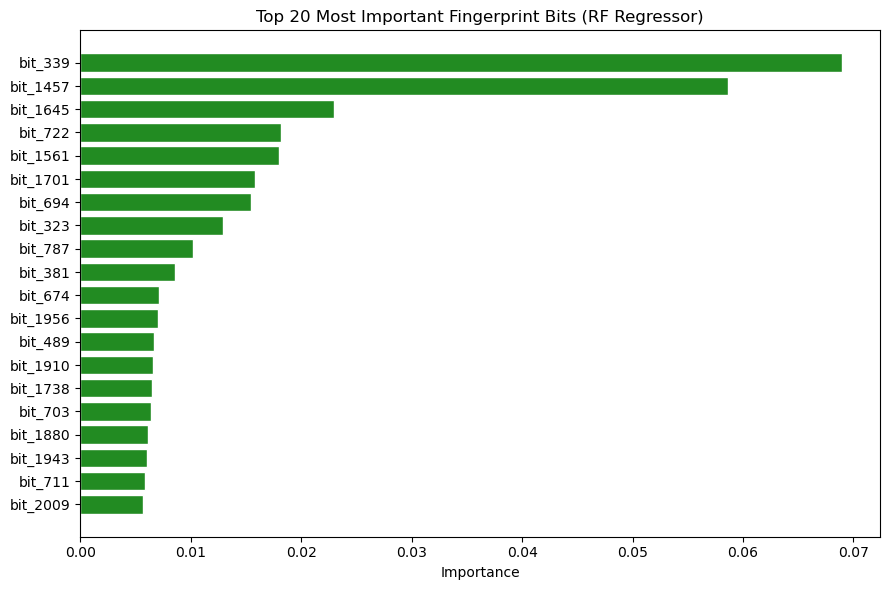

Plot saved to results/

Top bit: bit_339


In [10]:
importances = rf_reg.feature_importances_
top_n = 20
top_idx = np.argsort(importances)[-top_n:][::-1]

plt.figure(figsize=(9, 6))
plt.barh(
    [bit_cols[i] for i in top_idx][::-1],
    importances[top_idx][::-1],
    color='forestgreen', edgecolor='white'
)
plt.title(f'Top {top_n} Most Important Fingerprint Bits (RF Regressor)')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('../results/05_feature_importance.png', dpi=150)
plt.show()
print('Plot saved to results/')
print(f'\nTop bit: {bit_cols[top_idx[0]]}')

bit_339: atom 15, radius 1


[12:24:39] DEPRECATION WARNING: please use MorganGenerator
[12:24:39] DEPRECATION WARNING: please use MorganGenerator
[12:24:39] DEPRECATION WARNING: please use MorganGenerator
[12:24:39] DEPRECATION WARNING: please use MorganGenerator
[12:24:39] DEPRECATION WARNING: please use MorganGenerator
[12:24:39] DEPRECATION WARNING: please use MorganGenerator
[12:24:39] DEPRECATION WARNING: please use MorganGenerator
[12:24:39] DEPRECATION WARNING: please use MorganGenerator
[12:24:39] DEPRECATION WARNING: please use MorganGenerator
[12:24:39] DEPRECATION WARNING: please use MorganGenerator
[12:24:39] DEPRECATION WARNING: please use MorganGenerator
[12:24:39] DEPRECATION WARNING: please use MorganGenerator
[12:24:39] DEPRECATION WARNING: please use MorganGenerator
[12:24:39] DEPRECATION WARNING: please use MorganGenerator
[12:24:39] DEPRECATION WARNING: please use MorganGenerator
[12:24:39] DEPRECATION WARNING: please use MorganGenerator
[12:24:39] DEPRECATION WARNING: please use MorganGenerat

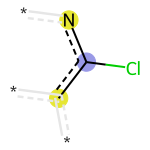

In [12]:
from rdkit import Chem
from rdkit.Chem import AllChem, Draw
from IPython.display import display
import pandas as pd

df_smiles = pd.read_csv('../data/processed/btk_curated.csv')

bit_to_inspect = 339

def get_bit_info(smi, bit_id, radius=2, n_bits=2048):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None
    bit_info = {}
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=n_bits, bitInfo=bit_info)
    if bit_id in bit_info:
        return mol, bit_info[bit_id]
    return None

example = None
for smi in df_smiles['canonical_smiles']:
    result = get_bit_info(smi, bit_to_inspect)
    if result is not None:
        example = result
        break

if example:
    mol, atom_radius_list = example
    atom_idx, radius = atom_radius_list[0]
    img = Draw.DrawMorganBit(mol, bit_to_inspect, {bit_to_inspect: atom_radius_list})
    if hasattr(img, 'save'):
        img.save('../results/05_bit339_substructure.png')
    else:
        with open('../results/05_bit339_substructure.png', 'wb') as f:
            f.write(img.data if hasattr(img, 'data') else img)
    print(f'bit_{bit_to_inspect}: atom {atom_idx}, radius {radius}')
    display(img)

## 11. Save Trained Models

In [11]:
joblib.dump(rf_reg, '../models/rf_btk_regressor.pkl')
joblib.dump(svr, '../models/svr_btk_regressor.pkl')

print('Models saved:')
print('  models/rf_btk_regressor.pkl')
print('  models/svr_btk_regressor.pkl')

Models saved:
  models/rf_btk_regressor.pkl
  models/svr_btk_regressor.pkl


## Observations

### Performance comparison (test set)

| Metric | Random Forest | SVR (subsample n=3,000) |
|--------|---------------|--------------------------|
| R² | **0.657** | 0.595 |
| RMSE | **0.703** | 0.764 |
| MAE | **0.509** | 0.558 |

**Random Forest outperformed SVR on every metric.** R² of 0.657 means
the model explains 65.7% of the variance in pIC50 across the test set —
a solid result for classical QSAR regression on a dataset this diverse
(pIC50 range: 3.00–12.59, spanning nearly 10 orders of magnitude in
IC50 concentration).

**Note on SVR training:** SVR was trained on a stratified subsample of
3,000 molecules due to computational constraints. RF had access to the
full 7,548-molecule training set, so the comparison slightly favors RF —
but reflects realistic constraints of kernel methods at this scale.

### Comparison with classification task (notebook 04)

The regression R² (0.657) is lower than what the classification AUC
(0.928) might suggest. This is expected: binary classification only
requires separating two groups, while regression must predict exact
continuous values across a 10-unit pIC50 range. The harder task
naturally yields lower performance.

### Most important fingerprint feature: bit_339

The top feature for the RF regressor is **bit_339**, decoded via RDKit
as a **chiral carbon center with nitrogen and chlorine substituents**
(N, Cl, and two additional groups in tetrahedral geometry). This differs
from the top classification feature (bit_575, aryl sulfonyl), which is
chemically meaningful:

- For **classification** (active/inactive), the dominant signal is the
  presence of hydrogen-bond acceptor groups that interact with the BTK
  hinge region (sulfonyl/sulfonamide)
- For **regression** (predicting exact potency), local chemical geometry
  around a chiral center — encoding which substituents surround a key
  carbon — carries additional information about fine-grained
  structure-activity relationships

**Important limitation:** ECFP4 does not encode stereochemistry
directly — two enantiomers produce identical fingerprint vectors by
default. What bit_339 captures is the *chemical neighborhood* around
that carbon (N, Cl, and adjacent groups), not the R/S configuration
itself. This is an inherent ceiling of 2D fingerprint-based QSAR for
chiral molecules, and a strong motivation for 3D-aware representations
in future work (e.g., graph neural networks with stereochemical features).

### Predicted vs actual plots

Both models show the characteristic compression toward the mean at
extreme pIC50 values (very weak <4 or very potent >10 compounds) —
a known limitation of RF (tree-based models cannot extrapolate beyond
the training range) and SVR. Predictions are most reliable for
compounds in the 5.5–9.5 pIC50 range, which represents the bulk of
the dataset.

## Summary

| Item | Value |
|------|-------|
| Training set | *(see output)* molecules |
| Test set | *(see output)* molecules |
| RF — Test R² | *(see output)* |
| SVR — Test R² | *(see output)* |
| RF — Test RMSE | *(see output)* |
| SVR — Test RMSE | *(see output)* |

**Next:** hyperparameter tuning (GridSearchCV) for both classification and
regression models, and addressing class imbalance in the classifier.